## Effect Heterogenity

### Resumen del Capítulo: Heterogeneidad de Efectos

En este capítulo, exploraremos uno de los desarrollos más interesantes de la inferencia causal aplicada a la industria: **la heterogeneidad de efectos**. A continuación, se resumen los puntos clave que se abordarán:

- **Concepto de Heterogeneidad de Efectos**:
    - Comprender cómo el impacto de un tratamiento puede variar entre diferentes individuos o grupos.
    - La importancia de identificar qué unidades responden mejor a un tratamiento para personalizar decisiones.

- **Desafíos en la Estimación de Heterogeneidad**:
    - Dificultades teóricas y prácticas al estimar efectos heterogéneos.
    - Métodos para adaptar los conocimientos previos y superar estos desafíos.

- **Relación con Problemas Predictivos**:
    - Conexión entre la estimación de efectos heterogéneos y problemas de predicción.
    - Aplicación de conceptos como validación cruzada y selección de modelos en este contexto.

- **Validación de Estimaciones de Efectos**:
    - Retos adicionales en la validación de modelos de heterogeneidad de efectos frente a modelos predictivos simples.
    - Introducción a ideas novedosas para evaluar la validez de las estimaciones.

- **Aplicaciones Prácticas y Toma de Decisiones**:
    - Ejemplos y directrices para usar la heterogeneidad de efectos en problemas empresariales.
    - Inspiración para aplicar estas ideas en contextos específicos.

Este capítulo busca proporcionar tanto una base teórica como herramientas prácticas para aprovechar la heterogeneidad de efectos en la toma de decisiones personalizadas.

In [28]:
import polars as pl
from plotnine import *

In [29]:
data = pl.read_csv("../data/daily_restaurant_sales.csv")
data.head()

rest_id,day,month,weekday,weekend,is_holiday,is_dec,is_nov,competitors_price,discounts,sales
i64,str,i64,i64,bool,bool,bool,bool,f64,i64,f64
0,"""2016-01-01""",1,4,false,true,false,false,2.88,0,79.0
0,"""2016-01-02""",1,5,true,false,false,false,2.64,0,57.0
0,"""2016-01-03""",1,6,true,false,false,false,2.08,5,294.0
0,"""2016-01-04""",1,0,false,false,false,false,3.37,15,676.5
0,"""2016-01-05""",1,1,false,false,false,false,3.79,0,66.0


In [30]:
import statsmodels.formula.api as smf

X = ["C(month)", "C(weekday)", "is_holiday", "competitors_price",]
regr_cate = smf.ols(
    f"sales ~ discounts * ({' + '.join(X)})", data.to_pandas()
).fit()

In [31]:
print(f"sales ~ discounts * ({' + '.join(X)})")

sales ~ discounts * (C(month) + C(weekday) + is_holiday + competitors_price)


In [32]:
ols_cate_pred = (
    regr_cate.predict(data.with_columns(
        discounts=(data.select(pl.col("discounts")).to_numpy().ravel() + 1)
        ).to_pandas()
    ) - regr_cate.predict(data.to_pandas())
)
ols_cate_pred

0       53.302535
1       48.652492
2       47.547577
3       43.195858
4       42.108752
          ...    
7674    42.197410
7675    28.919270
7676    38.855831
7677    33.862166
7678    26.322954
Length: 7679, dtype: float64

## Evaluating CATE Predictions

In [33]:
train =  data.filter(pl.col("day") < "2018-01-01")
test = data.filter(pl.col("day") >= "2018-01-01")

In [34]:
X = ["C(month)", "C(weekday)", "is_holiday", "competitors_price",]
regr_model = smf.ols(
    f"sales ~ discounts * ({' + '.join(X)})", train.to_pandas()
).fit()

In [35]:
cate_pred = (
    regr_cate.predict(test.with_columns(
        discounts=(test.select(pl.col("discounts")).to_numpy().ravel() + 1)
        ).to_pandas()
    ) - regr_cate.predict(test.to_pandas())
)
cate_pred

0       40.473667
1       44.451856
2       39.781592
3       40.693806
4       40.104459
          ...    
2557    42.197410
2558    28.919270
2559    38.855831
2560    33.862166
2561    26.322954
Length: 2562, dtype: float64

In [36]:
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

X = ["month", "weekday", "is_holiday", "competitors_price", "discounts"]
y = "sales"

np.random.seed(1)

ml_model = GradientBoostingRegressor(n_estimators=50).fit(train.select(X).to_numpy(), train.select(y).to_numpy().ravel())

ml_pred = ml_model.predict(test.select(X).to_numpy())

In [37]:
np.random.seed(123)

test_pred = test.with_columns(
    ml_pred=pl.Series(ml_pred),
    cate_pred=pl.Series(cate_pred),
    rand_m_pred=pl.Series(np.random.normal(0, 1, test.height))
)

test_pred.select("rest_id", "day", "sales", "ml_pred", "cate_pred", "rand_m_pred")

rest_id,day,sales,ml_pred,cate_pred,rand_m_pred
i64,str,f64,f64,f64,f64
0,"""2018-01-01""",251.5,236.31296,40.473667,-1.085631
0,"""2018-01-02""",541.0,470.21805,44.451856,0.997345
0,"""2018-01-03""",431.0,429.180652,39.781592,0.282978
0,"""2018-01-04""",760.0,769.159322,40.693806,-1.506295
0,"""2018-01-05""",78.0,83.42607,40.104459,-0.5786
…,…,…,…,…,…
6,"""2018-12-28""",771.0,598.981916,42.19741,-1.111479
6,"""2018-12-29""",229.0,236.103487,28.91927,-0.943911
6,"""2018-12-30""",458.0,411.551171,38.855831,0.680738


## Effect by Model Quantile

In [38]:
from toolz import curry

@curry
def addN(x, N):
    return x + N

ad5 = addN(N=5)
ad13 = addN(N=13)

print(ad5(10))  # Resultado esperado: 15
print(ad13(10))  # Resultado esperado: 23

15
23


In [39]:
@curry
def effect(df, y, t):
    df = pl.DataFrame(df)
    t_vals = df.select(t).to_numpy().ravel()
    y_vals = df.select(y).to_numpy().ravel()
    
    if len(t_vals) < 2: return 0.0
    
    t_diff = t_vals - t_vals.mean()
    denominator = np.sum(t_diff**2)
    
    if np.isclose(denominator, 0): return 0.0 
        
    return np.sum(t_diff * y_vals) / denominator

In [40]:
effect(test, "sales", "discounts")

np.float64(32.16196368039615)

In [41]:
def effect_by_quantile(df, pred, y, t, q=10):
    # Calculamos los cortes (usando alias para evitar DuplicateError)
    quantiles = df.select(
        [pl.col(pred).quantile(q_val).alias(f"q_{i}") 
         for i, q_val in enumerate(np.linspace(0, 1, q + 1))]
    ).to_numpy().ravel()
    
    effects = []
    for i in range(q):
        # Filtramos el grupo
        df_q = df.filter(
            (pl.col(pred) >= quantiles[i]) & (pl.col(pred) <= quantiles[i + 1])
        )
        
        # Usamos la nueva función robusta
        eff = effect(df_q, y, t)
        
        # Guardamos el punto medio y el efecto
        mid_point = (quantiles[i] + quantiles[i + 1]) / 2
        effects.append((mid_point, eff))

    # Devolvemos un DataFrame limpio de Polars
    return pl.DataFrame(effects, schema={pred: pl.Float64, "effect": pl.Float64}, orient="row")

In [42]:
effect_by_quantile(test_pred, "cate_pred", y="sales", t="discounts")

cate_pred,effect
f64,f64
17.792218,20.170921
24.090364,25.028748
27.0338,27.347438
29.113992,28.504469
30.930525,29.423342
32.798437,31.485922
34.729991,36.481232
36.81657,36.515903
39.473083,39.299573


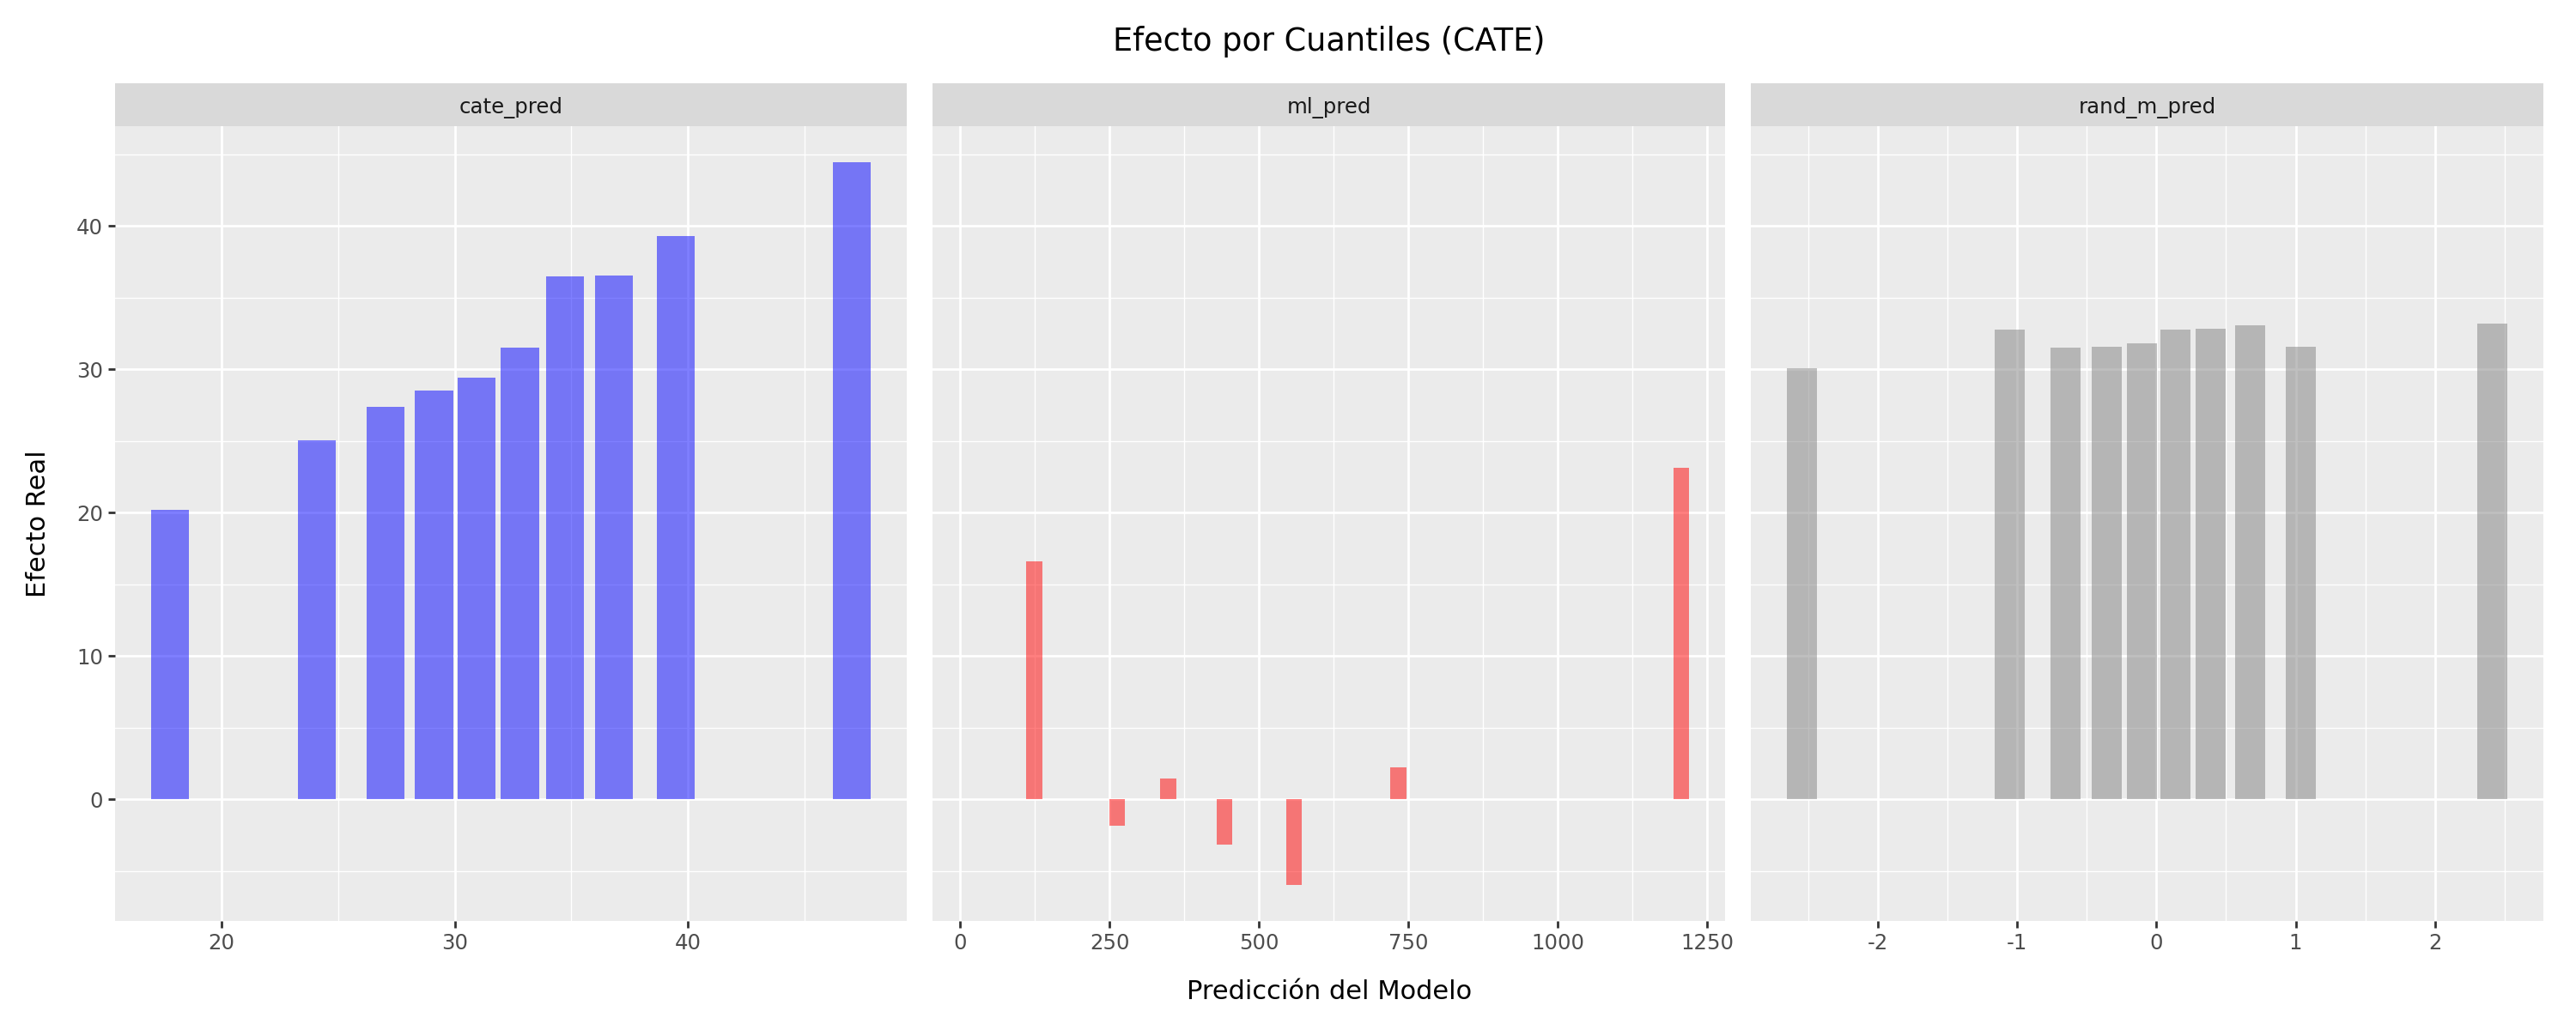

In [43]:
from plotnine import *

cate_pred = effect_by_quantile(test_pred, "cate_pred", y="sales", t="discounts")
ml_pred = effect_by_quantile(test_pred, "ml_pred", y="sales", t="discounts")
rand_m_pred = effect_by_quantile(test_pred, "rand_m_pred", y="sales", t="discounts")



(
    ggplot() +
    geom_col(data=cate_pred.with_columns(
        type=pl.lit("cate_pred")).to_pandas(), 
        mapping=aes(x="cate_pred", y="effect"), 
        fill="blue", alpha=0.5) +
    geom_col(data=ml_pred.with_columns(
        type=pl.lit("ml_pred")).to_pandas(), 
        mapping=aes(x="ml_pred", y="effect"), 
        fill="red", alpha=0.5) +
    geom_col(data=rand_m_pred.with_columns(
        type=pl.lit("rand_m_pred")).to_pandas(), 
        mapping=aes(x="rand_m_pred", y="effect"), 
        fill="grey", alpha=0.5) +
    facet_wrap("~type", scales="free_x") +
    theme(figure_size=(15, 6)) +
    labs(title="Efecto por Cuantiles (CATE)", x="Predicción del Modelo", y="Efecto Real")
)

## Cumulative Effect

In [44]:
def cumulative_effect_curve(dataset, prediction, y, t,
    ascending=False, steps=100):
    size = len(dataset)
    ordered_df = (dataset
    .sort_values(prediction, ascending=ascending)
    .reset_index(drop=True))
    steps = np.linspace(size/steps, size, steps).round(0)
    return np.array([effect(ordered_df.query(f"index<={row}"), t=t, y=y)
    for row in steps])
cumulative_effect_curve(test_pred.to_pandas(), "cate_pred", "sales", "discounts")

array([49.60383609, 49.0940406 , 45.66307581, 45.88178441, 45.44954697,
       45.21560442, 44.99224212, 44.97429036, 44.49921659, 44.43186458,
       44.22030877, 43.44703468, 43.36016371, 42.89398243, 42.5662768 ,
       42.16075567, 42.14803605, 41.80717477, 41.63591781, 41.4235265 ,
       41.22222076, 41.1798033 , 41.04859735, 40.70360566, 40.52421135,
       40.39763723, 40.32627481, 40.06449904, 39.72761783, 39.55484824,
       39.63811418, 39.49524939, 39.43539761, 39.31476093, 39.1470357 ,
       39.1124127 , 39.02682885, 38.9269031 , 38.92665509, 38.92604128,
       38.88802381, 38.8552866 , 38.57723209, 38.40097134, 38.21020122,
       38.08842563, 37.99529808, 37.8153454 , 37.75669275, 37.57139745,
       37.4564538 , 37.37702628, 37.19680747, 37.01055999, 36.95277987,
       36.78877515, 36.7110297 , 36.66102393, 36.48585585, 36.37056364,
       36.21279454, 36.12319675, 35.94492221, 35.67562072, 35.49640125,
       35.43495556, 35.35955023, 35.30099905, 35.2687742 , 35.18

In [45]:
ce_cate = pl.DataFrame(cumulative_effect_curve(test_pred.to_pandas(), "cate_pred", "sales", "discounts"),  schema= { "effect": pl.Float64 })
ce_ml = pl.DataFrame(cumulative_effect_curve(test_pred.to_pandas(), "ml_pred", "sales", "discounts"), schema= { "effect": pl.Float64 })
ce_rand = pl.DataFrame(cumulative_effect_curve(test_pred.to_pandas(), "rand_m_pred", "sales", "discounts"), schema= { "effect": pl.Float64 })

# Array de porcentajes para el eje x
percentiles = np.linspace(1, 100, 100)

avg_effect_val = cumulative_effect_curve(test_pred.to_pandas(), "cate_pred", "sales", "discounts")[-1]


ce_cate = ce_cate.with_columns(
    percentiles=pl.Series(percentiles)
)
ce_ml = ce_ml.with_columns(
    percentiles=pl.Series(percentiles)
)
ce_rand = ce_rand.with_columns(
    percentiles=pl.Series(percentiles)
)


df_plot = pl.concat([
    ce_cate.with_columns(tipo=pl.lit("cate_pred")),
    ce_ml.with_columns(tipo=pl.lit("ml_pred")),
    ce_rand.with_columns(tipo=pl.lit("rand_m_pred"))
])

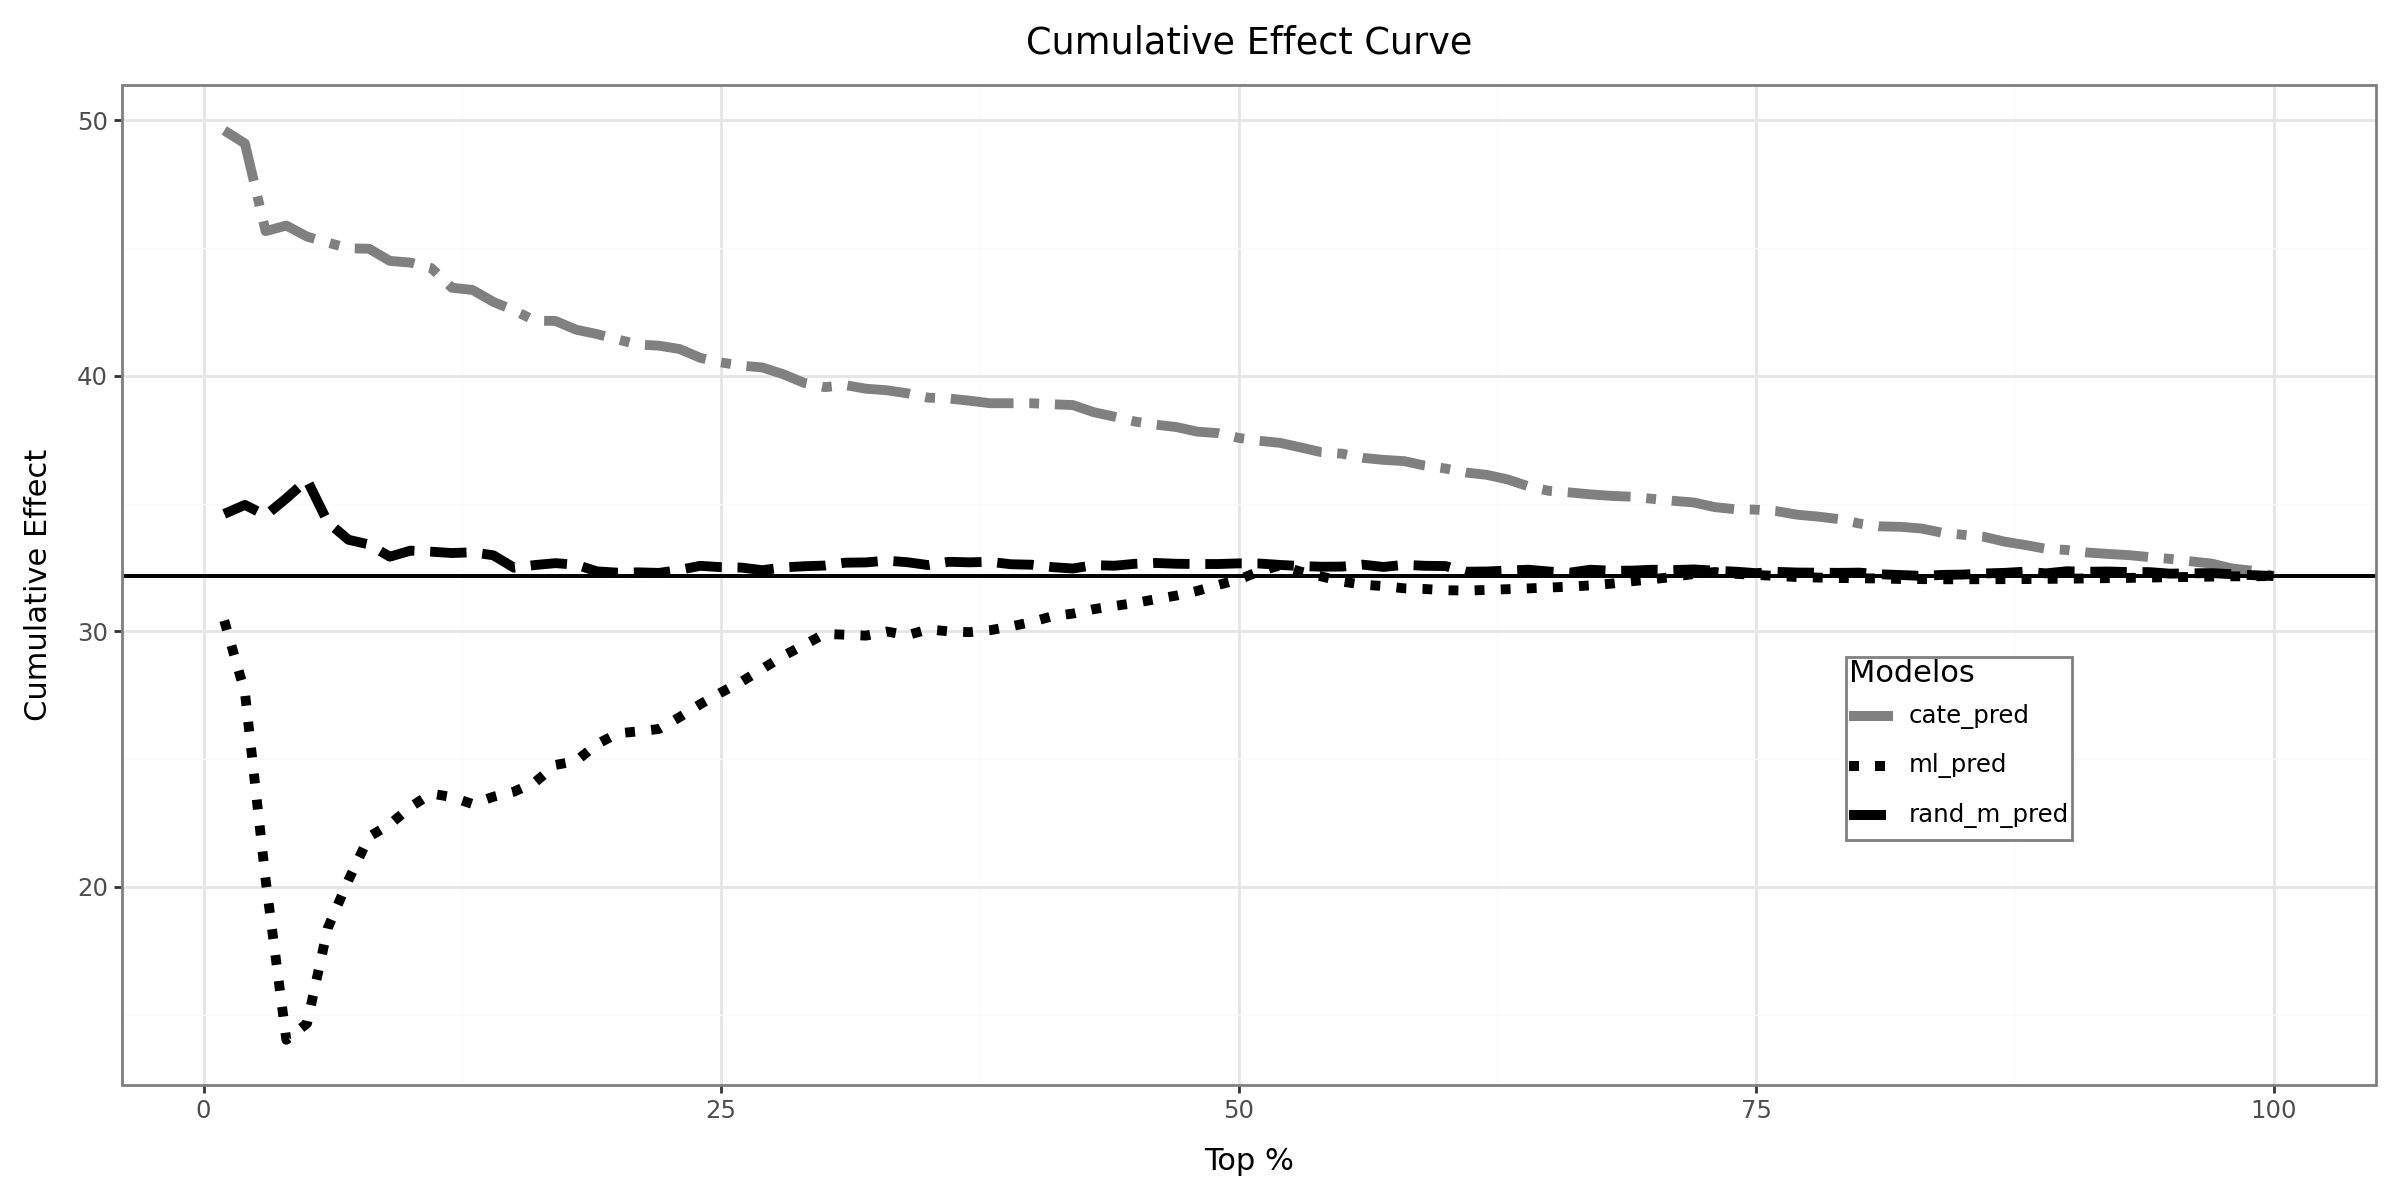

In [46]:


# 2. El Gráfico
(
    ggplot(df_plot, aes(x="percentiles", y="effect"))
    # Al mapear linetype y color a la columna 'tipo', plotnine crea la leyenda sola
    + geom_line(aes(linetype="tipo", color="tipo"), size=2)
    
    # Línea horizontal para la media (Avg. Effect)
    + geom_hline(yintercept=avg_effect_val, 
                 linetype="solid", 
                 color="black", 
                 size=0.8)
    
    # PERSONALIZACIÓN DE ESTILOS (Para que coincida con la imagen)
    + scale_linetype_manual(
        name="Modelos",
        values={
            "cate_pred": "dashdot",  # Línea irregular gris
            "ml_pred": "dotted",     # Línea de puntos inferior
            "rand_m_pred": "dashed"  # Línea discontinua
        }
    )
    + scale_color_manual(
        name="Modelos",
        values={
            "cate_pred": "gray", 
            "ml_pred": "black", 
            "rand_m_pred": "black"
        }
    )
    
    # Estética final y etiquetas
    + theme_bw()
    + theme(
        figure_size=(12, 6),
        legend_position=(0.85, 0.3), # Mueve la leyenda adentro como en la imagen
        legend_background=element_rect(fill="white", color="gray")
    )
    + labs(
        title="Cumulative Effect Curve",
        x="Top %",
        y="Cumulative Effect"
    )
)

## Cumulative Gain

In [47]:
import numpy as np

def cumulative_gain_curve(df, prediction, y, t,
    ascending=False, normalize=False, steps=100):
    """
    Calcula la curva de ganancia acumulada para un modelo de predicción de efectos heterogéneos.
    df: DataFrame de Polars o Pandas.
    prediction: columna de predicción del modelo (str).
    y: variable de resultado (str).
    t: variable de tratamiento (str).
    ascending: si True, ordena de menor a mayor predicción.
    normalize: si True, resta el efecto promedio.
    steps: número de puntos en la curva.
    """
    # Convertimos a pandas si es polars
    if hasattr(df, "to_pandas"):
        df = df.to_pandas()
    df = df.copy()
    df = df.reset_index(drop=True)
    df["index"] = df.index

    effect_fn = effect(y=y, t=t)
    normalizer = effect_fn(df) if normalize else 0
    size = len(df)
    ordered_df = df.sort_values(prediction, ascending=ascending).reset_index(drop=True)
    ordered_df["index"] = ordered_df.index

    steps_arr = np.linspace(size/steps, size, steps).round(0).astype(int)
    effects = []
    for row in steps_arr:
        subset = ordered_df.query(f"index<={row}")
        eff = (effect_fn(subset) - normalizer) * (row / size)
        effects.append(eff)
    return np.array([0] + effects)

cumulative_gain_curve(test_pred, "cate_pred", "sales", "discounts")

array([ 0.        ,  0.50339568,  0.97728184,  1.37238752,  1.82667526,
        2.27070336,  2.71787786,  3.14348608,  3.5986454 ,  4.01222445,
        4.43971793,  4.86734078,  5.20618253,  5.63580582,  6.0105151 ,
        6.37995718,  6.7470374 ,  7.17273369,  7.52268055,  7.91439968,
        8.27823793,  8.65634456,  9.06534311,  9.43701165,  9.77077185,
       10.12314413, 10.50149352, 10.89218664, 11.21243006, 11.5213193 ,
       11.87263009, 12.28441165, 12.64094633, 13.0066007 , 13.36579109,
       13.70604646, 14.07558334, 14.44084065, 14.79890851, 15.17866059,
       15.57345523, 15.93771468, 16.31861373, 16.59332934, 16.89223056,
       17.19608197, 17.52781179, 17.85571385, 18.15490821, 18.49517931,
       18.78569873, 19.10834704, 19.43255231, 19.71634057, 19.97876833,
       20.32258659, 20.60573472, 20.92041505, 21.26396626, 21.53263624,
       21.81949895, 22.09234889, 22.39017816, 22.64445919, 22.83685323,
       23.06850433, 23.38817714, 23.69724736, 24.00247476, 24.33

In [48]:
ce_cate = pl.DataFrame(cumulative_gain_curve(test_pred.to_pandas(), "cate_pred", "sales", "discounts"),  schema= { "effect": pl.Float64 })
ce_ml = pl.DataFrame(cumulative_gain_curve(test_pred.to_pandas(), "ml_pred", "sales", "discounts"), schema= { "effect": pl.Float64 })
ce_rand = pl.DataFrame(cumulative_gain_curve(test_pred.to_pandas(), "rand_m_pred", "sales", "discounts"), schema= { "effect": pl.Float64 })

# Array de porcentajes para el eje x
percentiles = np.linspace(1, 100, 101)

avg_effect_val = cumulative_effect_curve(test_pred.to_pandas(), "cate_pred", "sales", "discounts")[-1]


ce_cate = ce_cate.with_columns(
    percentiles=pl.Series(percentiles)
)
ce_ml = ce_ml.with_columns(
    percentiles=pl.Series(percentiles)
)
ce_rand = ce_rand.with_columns(
    percentiles=pl.Series(percentiles)
)


df_plot = pl.concat([
    ce_cate.with_columns(tipo=pl.lit("cate_pred")),
    ce_ml.with_columns(tipo=pl.lit("ml_pred")),
    ce_rand.with_columns(tipo=pl.lit("rand_m_pred"))
])

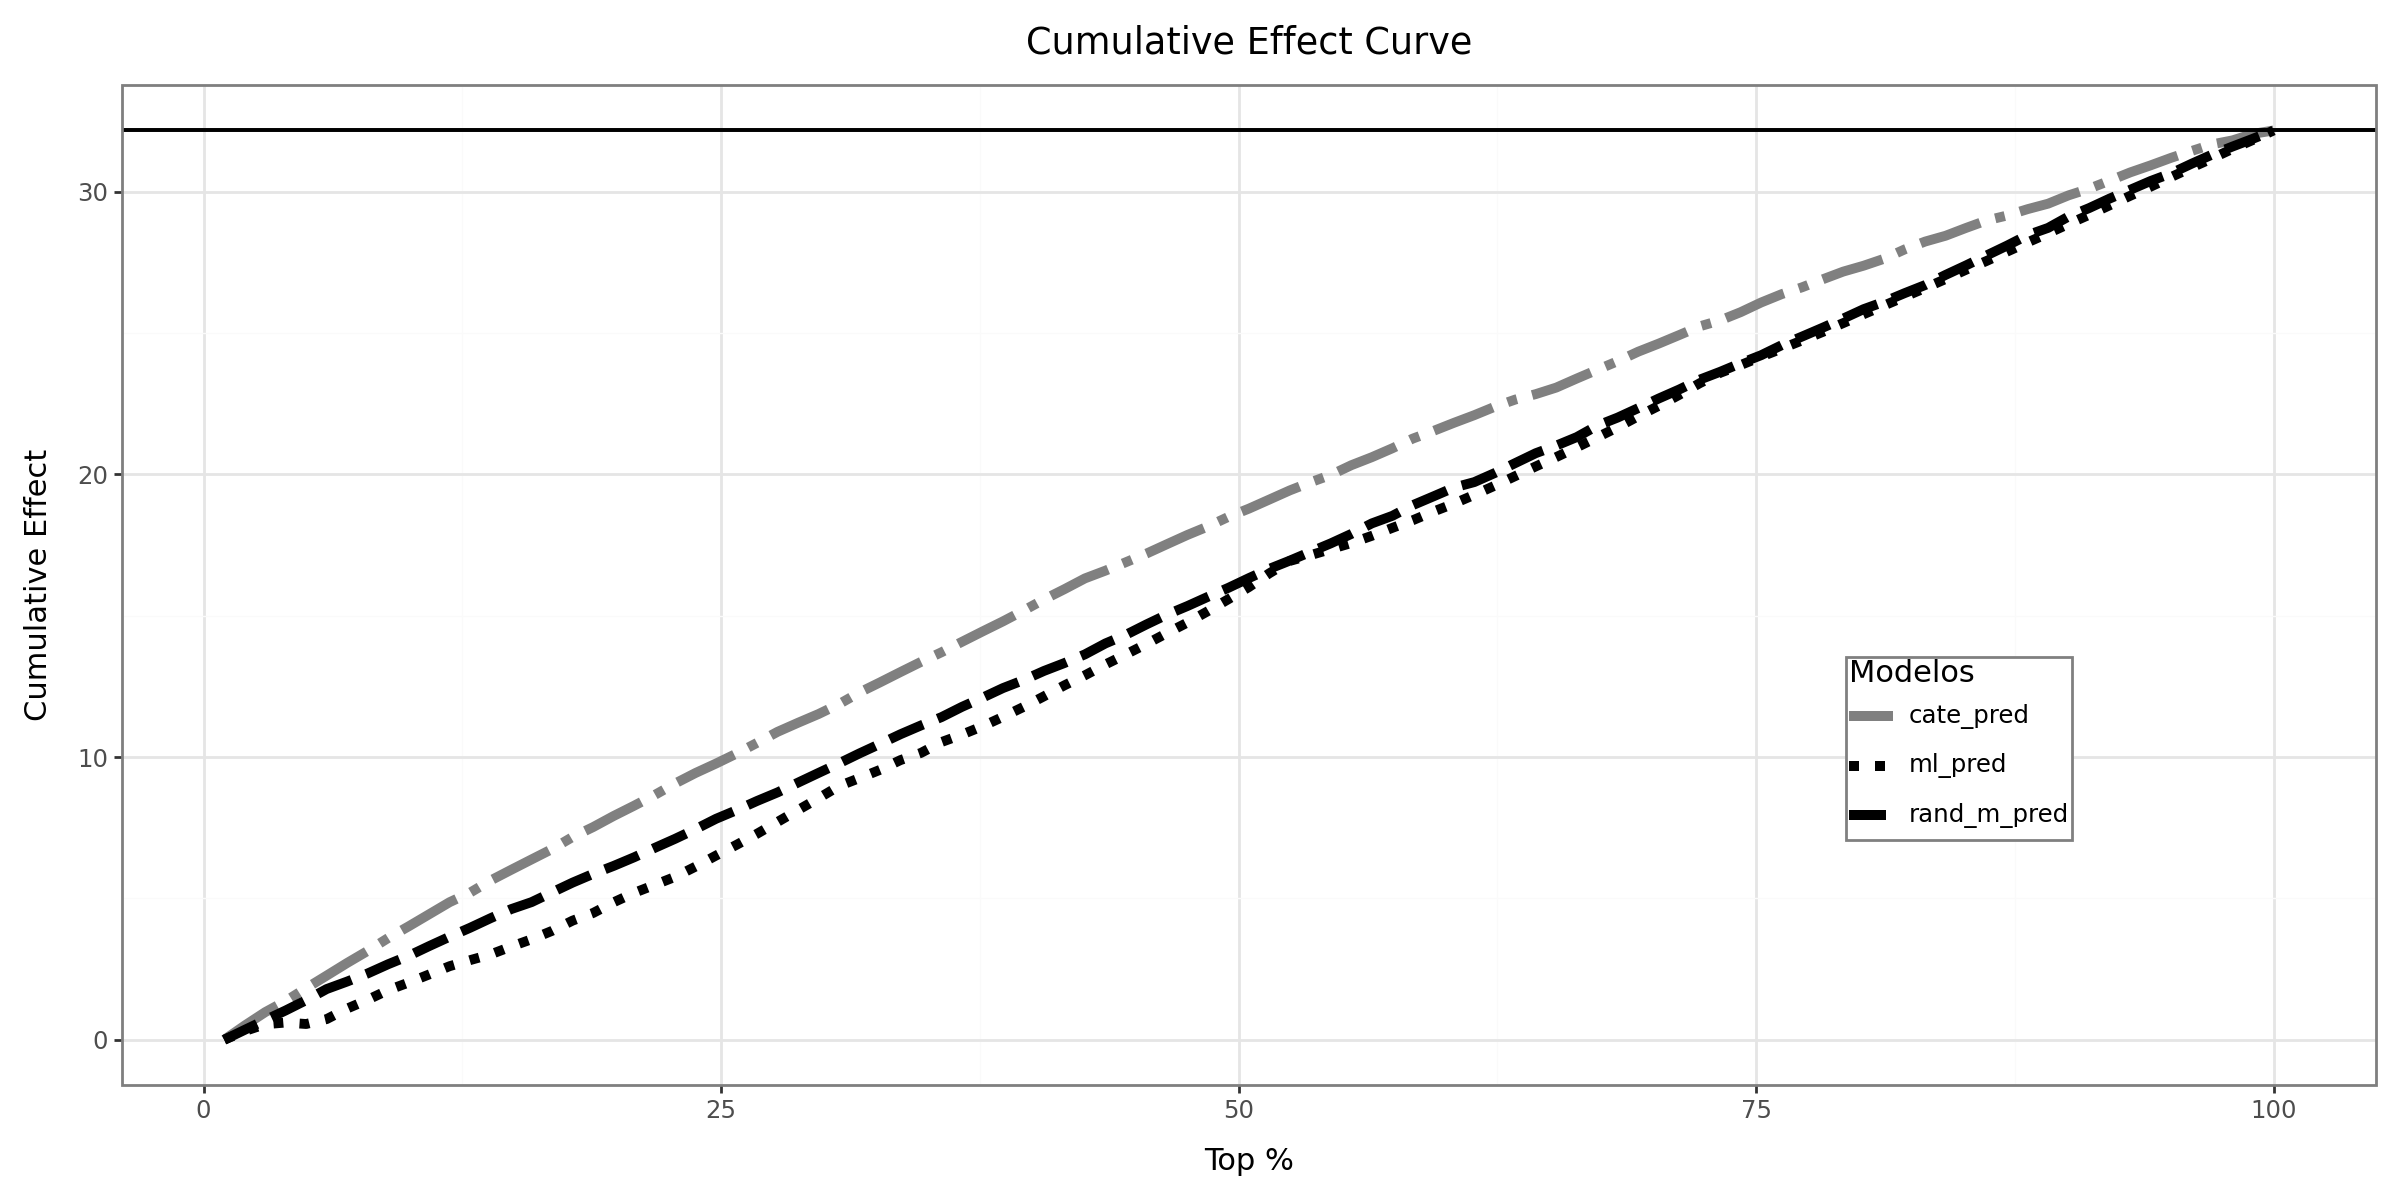

In [49]:


# 2. El Gráfico
(
    ggplot(df_plot, aes(x="percentiles", y="effect"))
    # Al mapear linetype y color a la columna 'tipo', plotnine crea la leyenda sola
    + geom_line(aes(linetype="tipo", color="tipo"), size=2)
    
    # Línea horizontal para la media (Avg. Effect)
    + geom_hline(yintercept=avg_effect_val, 
                 linetype="solid", 
                 color="black", 
                 size=0.8)
    
    # PERSONALIZACIÓN DE ESTILOS (Para que coincida con la imagen)
    + scale_linetype_manual(
        name="Modelos",
        values={
            "cate_pred": "dashdot",  # Línea irregular gris
            "ml_pred": "dotted",     # Línea de puntos inferior
            "rand_m_pred": "dashed"  # Línea discontinua
        }
    )
    + scale_color_manual(
        name="Modelos",
        values={
            "cate_pred": "gray", 
            "ml_pred": "black", 
            "rand_m_pred": "black"
        }
    )
    
    # Estética final y etiquetas
    + theme_bw()
    + theme(
        figure_size=(12, 6),
        legend_position=(0.85, 0.3), # Mueve la leyenda adentro como en la imagen
        legend_background=element_rect(fill="white", color="gray")
    )
    + labs(
        title="Cumulative Effect Curve",
        x="Top %",
        y="Cumulative Effect"
    )
)

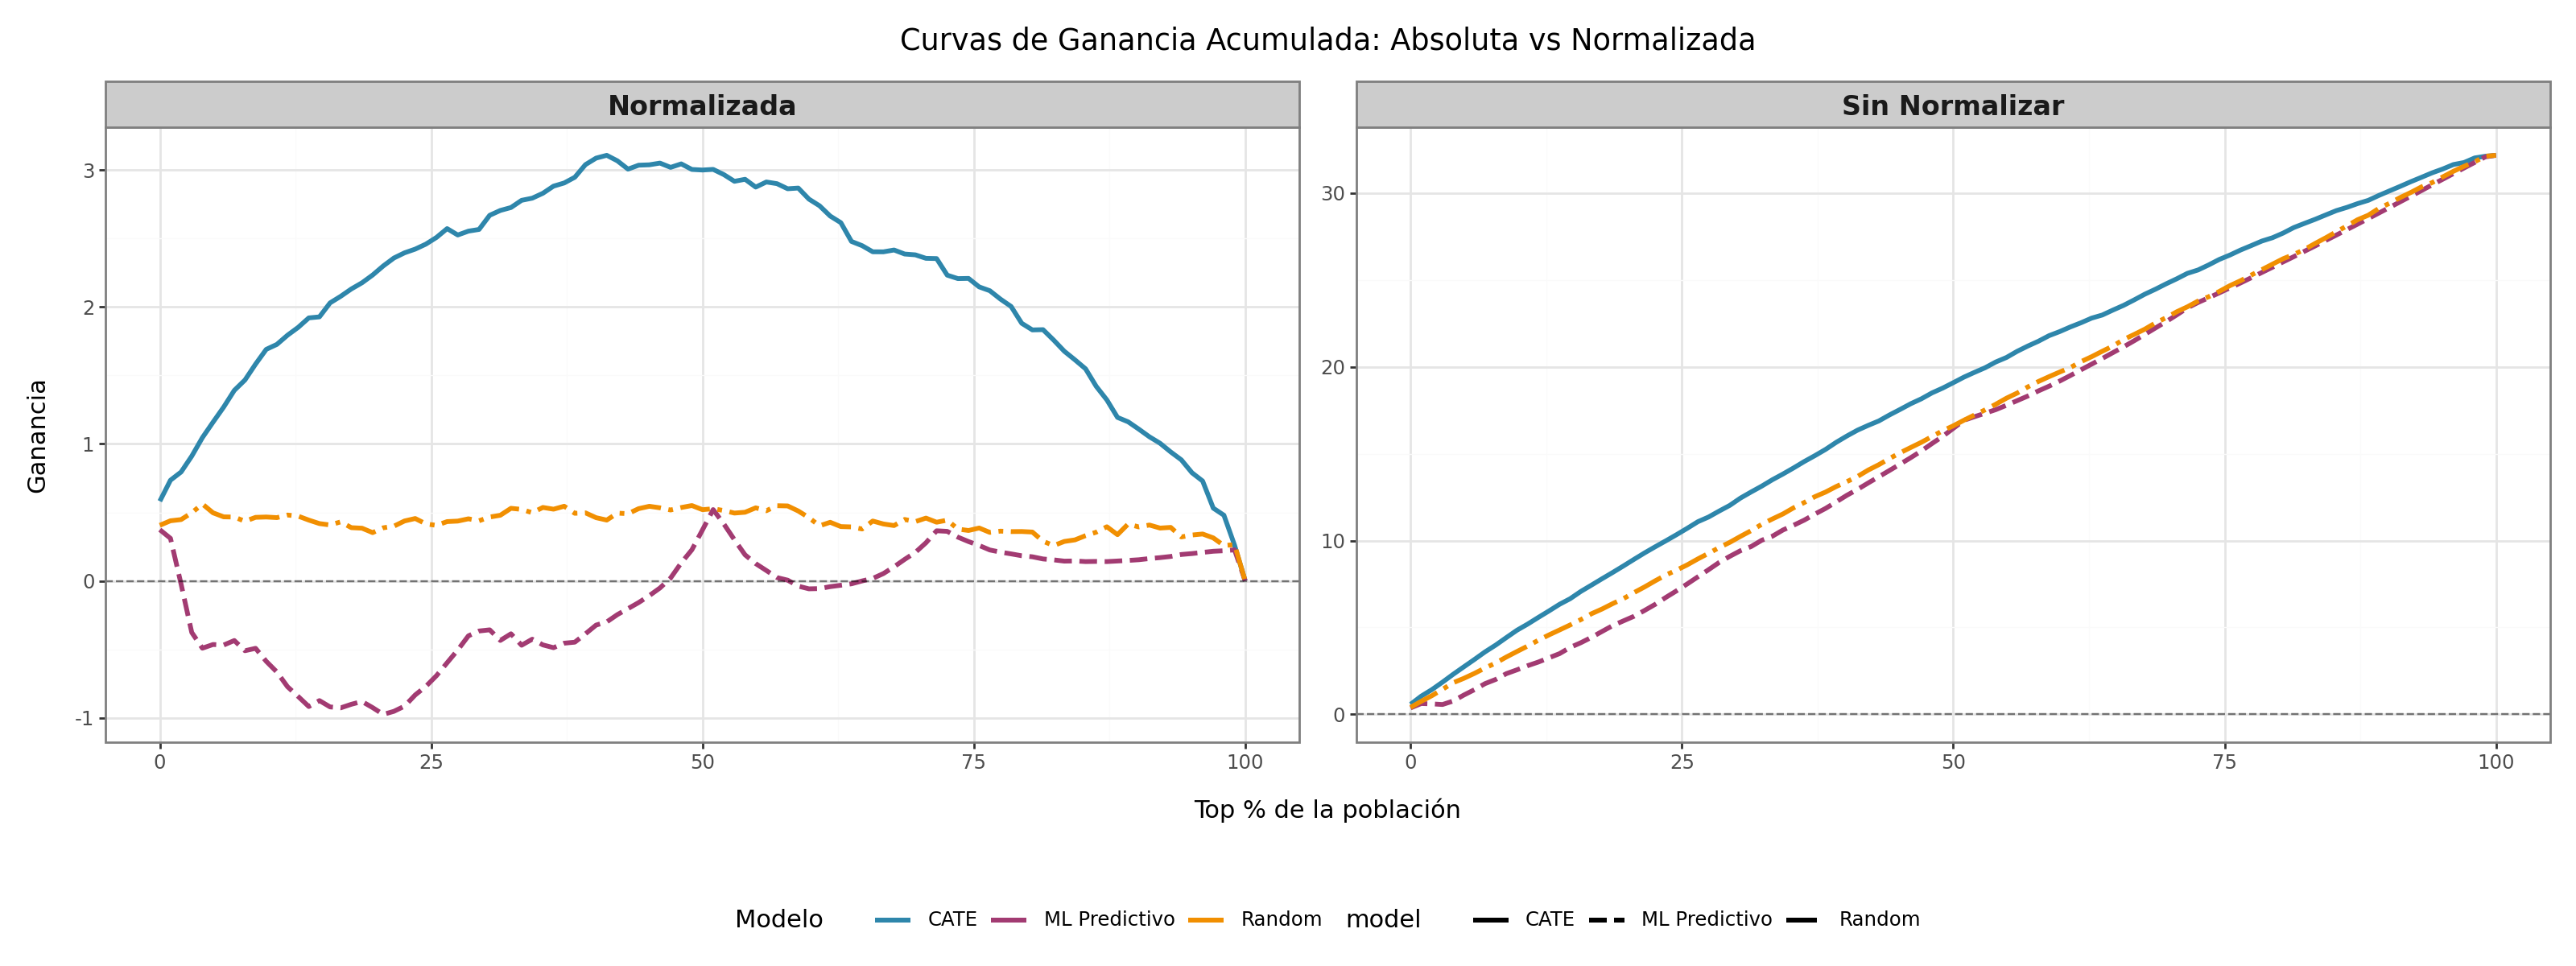

In [50]:

from fklearn.causal.validation.curves import cumulative_gain_curve as fk_cgc

models = ["cate_pred", "ml_pred", "rand_m_pred"]
labels = ["CATE", "ML Predictivo", "Random"]

data_list = []

for model, label in zip(models, labels):
    # 1. Calculamos la curva base (sin el argumento 'normalize' que da error)
    # Nota: Asegúrate del orden de columnas (df, t, y, pred)
    gain = fk_cgc(test_pred.to_pandas(), "discounts", "sales", model, steps=100)
    
    # 2. El ATE global es el último punto de la curva de ganancia
    ate_total = gain[-1]
    percentiles = np.linspace(0, 100, len(gain))
    
    # 3. Versión Sin Normalizar
    data_list.append(pl.DataFrame({
        "percentile": percentiles, 
        "gain": gain, 
        "model": label, 
        "tipo_curva": "Sin Normalizar"
    }))
    
    # 4. Versión Normalizada (Manual): (Gain - ATE * (proporción de población))
    # La teoría dice que restamos la diagonal del modelo aleatorio (ATE * proporción)
    gain_norm = gain - (ate_total * (percentiles / 100))
    
    data_list.append(pl.DataFrame({
        "percentile": percentiles, 
        "gain": gain_norm, 
        "model": label, 
        "tipo_curva": "Normalizada"
    }))

# Unimos y graficamos
df_facets = pl.concat(data_list)

(
    ggplot(df_facets.to_pandas(), aes(x="percentile", y="gain", color="model", linetype="model"))
    + geom_line(size=1.2)
    + geom_hline(yintercept=0, linetype="dashed", color="black", alpha=0.5)
    + facet_wrap("~tipo_curva", scales="free_y")
    + scale_color_manual(values={"CATE": "#2E86AB", "ML Predictivo": "#A23B72", "Random": "#F18F01"})
    + theme_bw()
    + theme(
        figure_size=(16, 6),
        legend_position="bottom",
        strip_text=element_text(size=12, weight="bold")
    )
    + labs(
        title="Curvas de Ganancia Acumulada: Absoluta vs Normalizada",
        x="Top % de la población",
        y="Ganancia",
        color="Modelo"
    )
)

In [51]:
for m in ["rand_m_pred", "ml_pred", "cate_pred"]:
    gain = cumulative_gain_curve(test_pred, m,
                                 "sales", "discounts", normalize=True)
    print(f"AUC for {m}:", sum(gain))

AUC for rand_m_pred: 13.06687257087794
AUC for ml_pred: -45.47353670940223
AUC for cate_pred: 182.26866466477983


### Transformación del Target para Aproximar el Efecto Causal

En problemas de inferencia causal, no podemos observar el efecto causal verdadero para cada individuo (el famoso "fundamental problem of causal inference"). Sin embargo, existe una técnica para construir una **variable objetivo (target)** que, en promedio, se aproxima al efecto causal individual esperado.

#### Intuición (Feynman style)
Imagina que quieres saber cuánto cambia la venta de un restaurante si le aplicas un descuento, pero solo puedes ver lo que ocurrió con el descuento real, no con el alternativo. La idea es construir una variable que, usando la información disponible, nos ayude a estimar ese efecto, aunque no lo veamos directamente.

#### Fórmula Matemática

La transformación propuesta es:

$$
Y_i^* = \frac{Y_i - \mu_{y|X_i}}{T_i - \mu_{t|X_i}}
$$

donde:
- $Y_i$ es el resultado observado (por ejemplo, ventas).
- $T_i$ es el tratamiento recibido (por ejemplo, descuento aplicado).
- $\mu_{y|X_i}$ es la media esperada de $Y$ dado las covariables $X_i$.
- $\mu_{t|X_i}$ es la media esperada de $T$ dado las covariables $X_i$.

#### ¿Por qué funciona?
- **En expectativa**, esta transformación elimina el sesgo introducido por las covariables $X$ y nos acerca al efecto causal individual.
- Es especialmente útil en métodos de aprendizaje automático para estimar efectos heterogéneos, ya que convierte el problema causal en uno supervisado.

#### Resumen en una frase
Construimos un "target" ajustado por covariables que, en promedio, se comporta como el efecto causal individual, permitiendo entrenar modelos para predecir efectos heterogéneos.



In [ ]:
# Calculo del target (CORREGIDO)

X = ["C(month)", "C(weekday)", "is_holiday", "competitors_price"]

y_res = smf.ols(f"sales ~ {' + '.join(X)}", test.to_pandas()).fit().resid
t_res = smf.ols(f"discounts ~ {' + '.join(X)}", test.to_pandas()).fit().resid

tau_hat = y_res / t_res


In [71]:
from sklearn.metrics import mean_squared_error

for m in ["rand_m_pred", "ml_pred", "cate_pred"]:
    wmse = mean_squared_error(tau_hat, test_pred.select(m).to_numpy().ravel(), sample_weight=t_res**2)
    print(f"MSE for {m}:", wmse)

MSE for rand_m_pred: 1115.780661672509
MSE for ml_pred: 576256.7425385385
MSE for cate_pred: 42.36037836070606



## 📊 Resumen: Modelos de Predicción y CATE para la Toma de Decisiones

---

### 1. ¿Cuándo los modelos predictivos ($Y$) sirven para ordenar el CATE?

- **Correlación clave:**  
    Un modelo que predice el resultado ($Y$) solo sirve para ordenar el efecto ($CATE$) si el resultado y el efecto están correlacionados.

- **El motor es la no linealidad:**  
    Esto ocurre principalmente cuando la función de respuesta al tratamiento no es una línea recta.

---

### 2. Rendimientos Marginales Decrecientes (Concavidad) 📉

- **Punto de saturación:**  
    En negocios, llega un momento donde más tratamiento (ej. más presupuesto de marketing) produce cada vez menos impacto.

- **Regla de ordenamiento:**  
    A mayor resultado actual, menor es el efecto marginal.

- **Estrategia:**  
    Si el modelo predice un resultado alto, el efecto suele ser bajo.  
    Ordenar por el inverso de la predicción de $Y$ suele dar un buen orden de CATE.

---

### 3. Resultados Binarios (La curva en "S") 🎢

- **Forma sigmoide:**  
    El efecto es mayor en el centro de la curva (cerca del 50% de probabilidad).

- **Casos de baja probabilidad (Izquierda de la curva):**  
    Como en impagos bancarios o mortalidad por COVID.  
    Aquí, una mayor probabilidad base implica mayor sensibilidad al tratamiento.

- **Casos de alta probabilidad (Derecha de la curva):**  
    Como en conversiones de compra online.  
    Aquí, los que tienen más probabilidad de comprar son los menos sensibles a los descuentos (ya iban a comprar de todos modos).

---

### 4. CATE para la Toma de Decisiones 🎯

- **Tratamiento Binario:**
        - **Suministro ilimitado:**  
            Tratar a todos los que tengan $CATE > 0$.
        - **Suministro limitado:**  
            Ordenar por CATE y tratar a los "top N" con mayor efecto positivo.

- **Tratamiento Continuo (Dosis):**  
    Se debe optimizar la dosis para cada individuo equilibrando beneficios (ingresos) vs. costos.

---

### 5. Optimización de Precios y Ganancias 💸

- **La sensibilidad ($\tau$) como pendiente:**  
    El CATE representa qué tan sensible es la demanda a los cambios de precio.

- **Fórmula del precio óptimo ($P^*$):**  
    Se obtiene igualando el ingreso marginal al costo marginal.  
    El modelo CATE nos da el valor de $\tau$ para encontrar ese precio ideal.

    $$
    \text{Ingreso marginal} = \text{Costo marginal}
    $$

- **Soluciones de Esquina:**  
    Ocurren cuando el óptimo es el máximo o mínimo permitido.  
    Ojo con los costos ocultos (ej. saturar al cliente con emails), que a veces no vemos pero afectan el valor a largo plazo.


